# EDA & Data Preprocessing — Teen Social Media Stress Analysis

**Người thực hiện:** Huyền  
**Mục tiêu:** Phân tích dữ liệu sức khỏe tâm thần thanh thiếu niên liên quan đến mạng xã hội, tiền xử lý và chuẩn bị dữ liệu cho mô hình dự đoán.

---

## Giới thiệu

Dataset gồm **1200 học sinh (13–19 tuổi)** với 13 đặc trưng ghi lại hành vi sử dụng mạng xã hội và các chỉ số sức khỏe tâm thần.

**Biến mục tiêu:** `depression_label` (0 = không trầm cảm, 1 = có dấu hiệu trầm cảm)

---

## Mục lục
1. Import thư viện
2. Tải và khám phá dữ liệu thô (EDA)
3. Kiểm tra missing values và outliers
4. Trực quan hóa phân phối dữ liệu
5. Phân tích tương quan (Correlation Analysis)
6. Tiền xử lý (Preprocessing)
7. Feature Engineering
8. Xử lý mất cân bằng dữ liệu
9. Lưu kết quả

---
## 1. Import thư viện

Các thư viện cần dùng:
- **pandas / numpy**: đọc và xử lý dữ liệu dạng bảng
- **matplotlib / seaborn**: vẽ biểu đồ
- **sklearn**: công cụ tiền xử lý và machine learning
- **imbalanced-learn (SMOTE)**: xử lý dữ liệu mất cân bằng

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Cài đặt giao diện biểu đồ
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Đường dẫn (notebook nằm trong notebooks/, dùng ../ để lên thư mục gốc)
RAW_PATH   = '../data/raw/Teen_Mental_Health_Dataset.csv'
PROC_PATH  = '../data/processed/preprocessed_data.csv'
FIG_DIR    = '../figures/eda/'

import os
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('✅ Import thành công!')

✅ Import thành công!


---
## 2. Tải và khám phá dữ liệu thô (EDA)

**EDA (Exploratory Data Analysis)** là bước đầu tiên trong mọi dự án data science.  
Mục đích: *Hiểu dữ liệu mình đang làm việc với* — hình dạng, kiểu dữ liệu, phân phối, vấn đề tiềm ẩn.

In [2]:
df = pd.read_csv(RAW_PATH)

print(f'📊 Kích thước dataset: {df.shape[0]} hàng × {df.shape[1]} cột')
print()
df.head(10)

📊 Kích thước dataset: 1200 hàng × 13 cột



,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [3]:
# Thông tin tổng quan: kiểu dữ liệu, số giá trị khác null
print('📋 Thông tin các cột:')
df.info()

📋 Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory 

In [4]:
# Thống kê mô tả cho cột số
# count=số dòng hợp lệ, mean=trung bình, std=độ lệch chuẩn
# min/25%/50%/75%/max = phân vị
print('📈 Thống kê mô tả (cột số):')
df.describe().round(2)

📈 Thống kê mô tả (cột số):


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,1.74,2.99,1.01,5.45,5.64,5.56,0.03
std,2.02,2.03,1.44,0.72,0.58,0.58,2.90,2.86,2.83,0.16
min,13.00,1.00,4.00,0.50,2.00,0.00,1.00,1.00,1.00,0.00
25%,14.00,2.80,5.20,1.10,2.50,0.50,3.00,3.00,3.00,0.00
50%,16.00,4.50,6.50,1.80,2.99,1.00,5.00,6.00,6.00,0.00
75%,18.00,6.30,7.60,2.40,3.48,1.50,8.00,8.00,8.00,0.00
max,19.00,8.00,9.00,3.00,4.00,2.00,10.00,10.00,10.00,1.00


In [5]:
# Thống kê cho cột dạng chữ (categorical)
print('📝 Thống kê cột categorical:')
df.describe(include='object')

📝 Thống kê cột categorical:


,gender,platform_usage,social_interaction_level
count,1200,1200,1200
unique,2,3,3
top,male,Instagram,medium
freq,615,411,416


In [6]:
# Xem các giá trị unique trong cột categorical
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in cat_cols:
    print(f'  {col}: {df[col].unique()}')

  gender: ['male' 'female']
  platform_usage: ['Instagram' 'TikTok' 'Both']
  social_interaction_level: ['low' 'high' 'medium']


---
## 3. Kiểm tra Missing Values và Outliers

**Missing values (giá trị bị thiếu):** Nếu dữ liệu thiếu, mô hình sẽ không học được đúng.  
**Outliers (ngoại lệ):** Giá trị bất thường có thể làm lệch kết quả phân tích.

In [7]:
# --- Kiểm tra missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Số thiếu': missing, 'Tỉ lệ (%)': missing_pct})

print('🔍 Missing values theo cột:')
print(missing_df[missing_df['Số thiếu'] > 0] if missing.any() else '✅ Không có missing values!')

🔍 Missing values theo cột:
✅ Không có missing values!


In [8]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

print('🔎 Kiểm tra Outliers (phương pháp IQR):')
print(f"{'Cột':<30} {'Q1':>6} {'Q3':>6} {'IQR':>6} {'Số outlier':>12}")
print('-' * 65)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<30} {Q1:>6.2f} {Q3:>6.2f} {IQR:>6.2f} {n_out:>12}')

🔎 Kiểm tra Outliers (phương pháp IQR):
Cột                                Q1     Q3    IQR   Số outlier
-----------------------------------------------------------------
age                             14.00  18.00   4.00            0
daily_social_media_hours         2.80   6.30   3.50            0
sleep_hours                      5.20   7.60   2.40            0
screen_time_before_sleep         1.10   2.40   1.30            0
academic_performance             2.50   3.48   0.98            0
physical_activity                0.50   1.50   1.00            0
stress_level                     3.00   8.00   5.00            0
anxiety_level                    3.00   8.00   5.00            0
addiction_level                  3.00   8.00   5.00            0


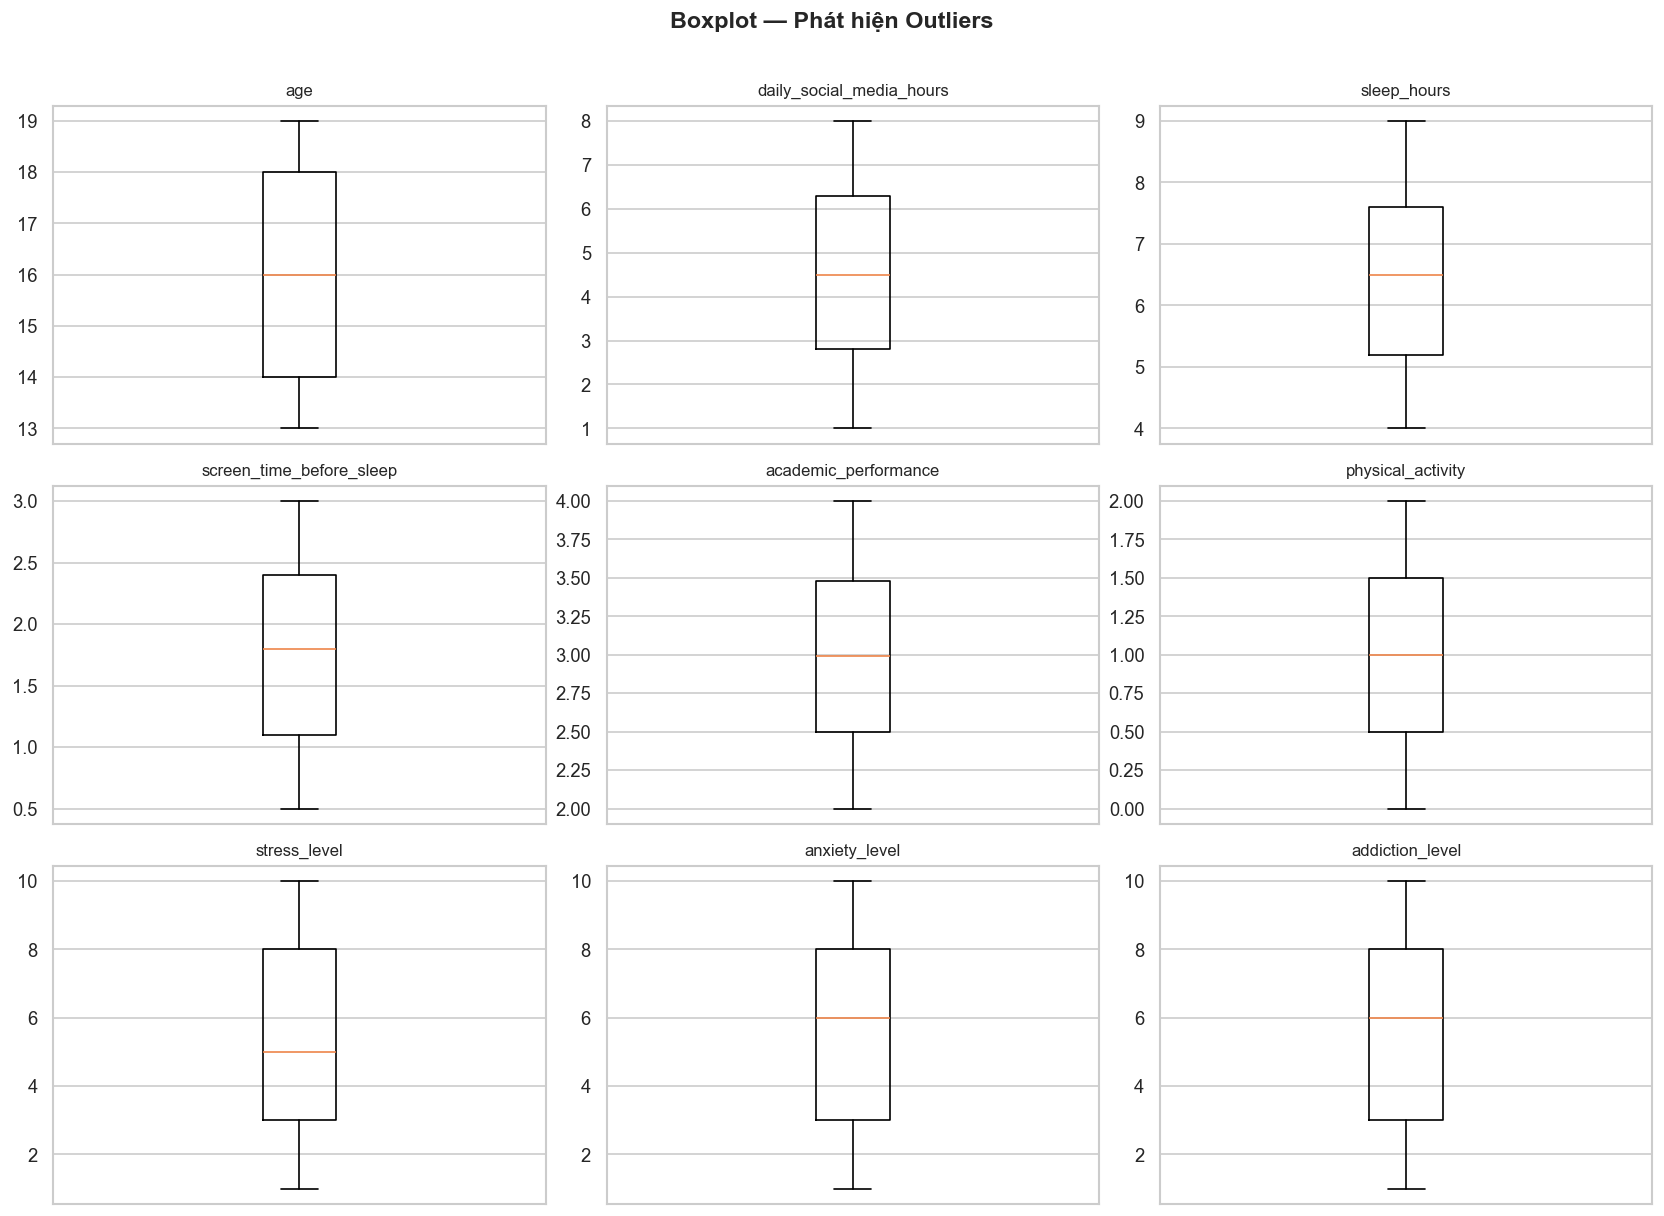

💾 Đã lưu: figures/boxplot_outliers.png


In [9]:
# Boxplot trực quan hóa outliers
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

plt.suptitle('Boxplot — Phát hiện Outliers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'boxplot_outliers.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/boxplot_outliers.png')

---
## 4. Trực quan hóa phân phối dữ liệu

Trực quan hóa giúp ta *thấy được* dữ liệu trông như thế nào — phân phối có đều không, có lệch không, biến mục tiêu có cân bằng không.

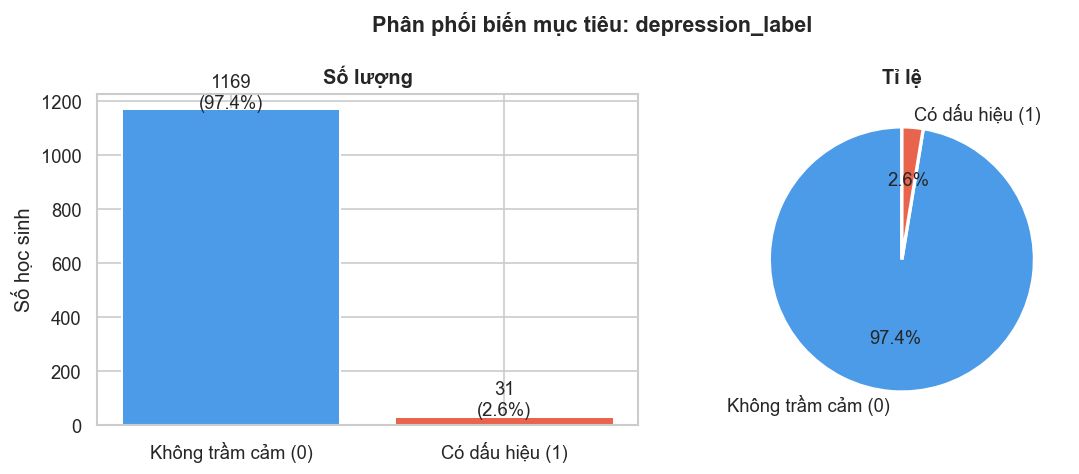

📊 Tỉ lệ: 0=97.4% | 1=2.6%


In [10]:
# --- 4.1 Phân phối biến mục tiêu (depression_label) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['depression_label'].value_counts()
labels = ['Không trầm cảm (0)', 'Có dấu hiệu (1)']

# Bar chart
axes[0].bar(labels, counts.values, color=['#4C9BE8', '#E8644C'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Số lượng', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số học sinh')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C9BE8', '#E8644C'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỉ lệ', fontsize=12, fontweight='bold')

plt.suptitle('Phân phối biến mục tiêu: depression_label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'target_distribution.png', bbox_inches='tight')
plt.show()
print(f'📊 Tỉ lệ: 0={counts[0]/len(df)*100:.1f}% | 1={counts[1]/len(df)*100:.1f}%')

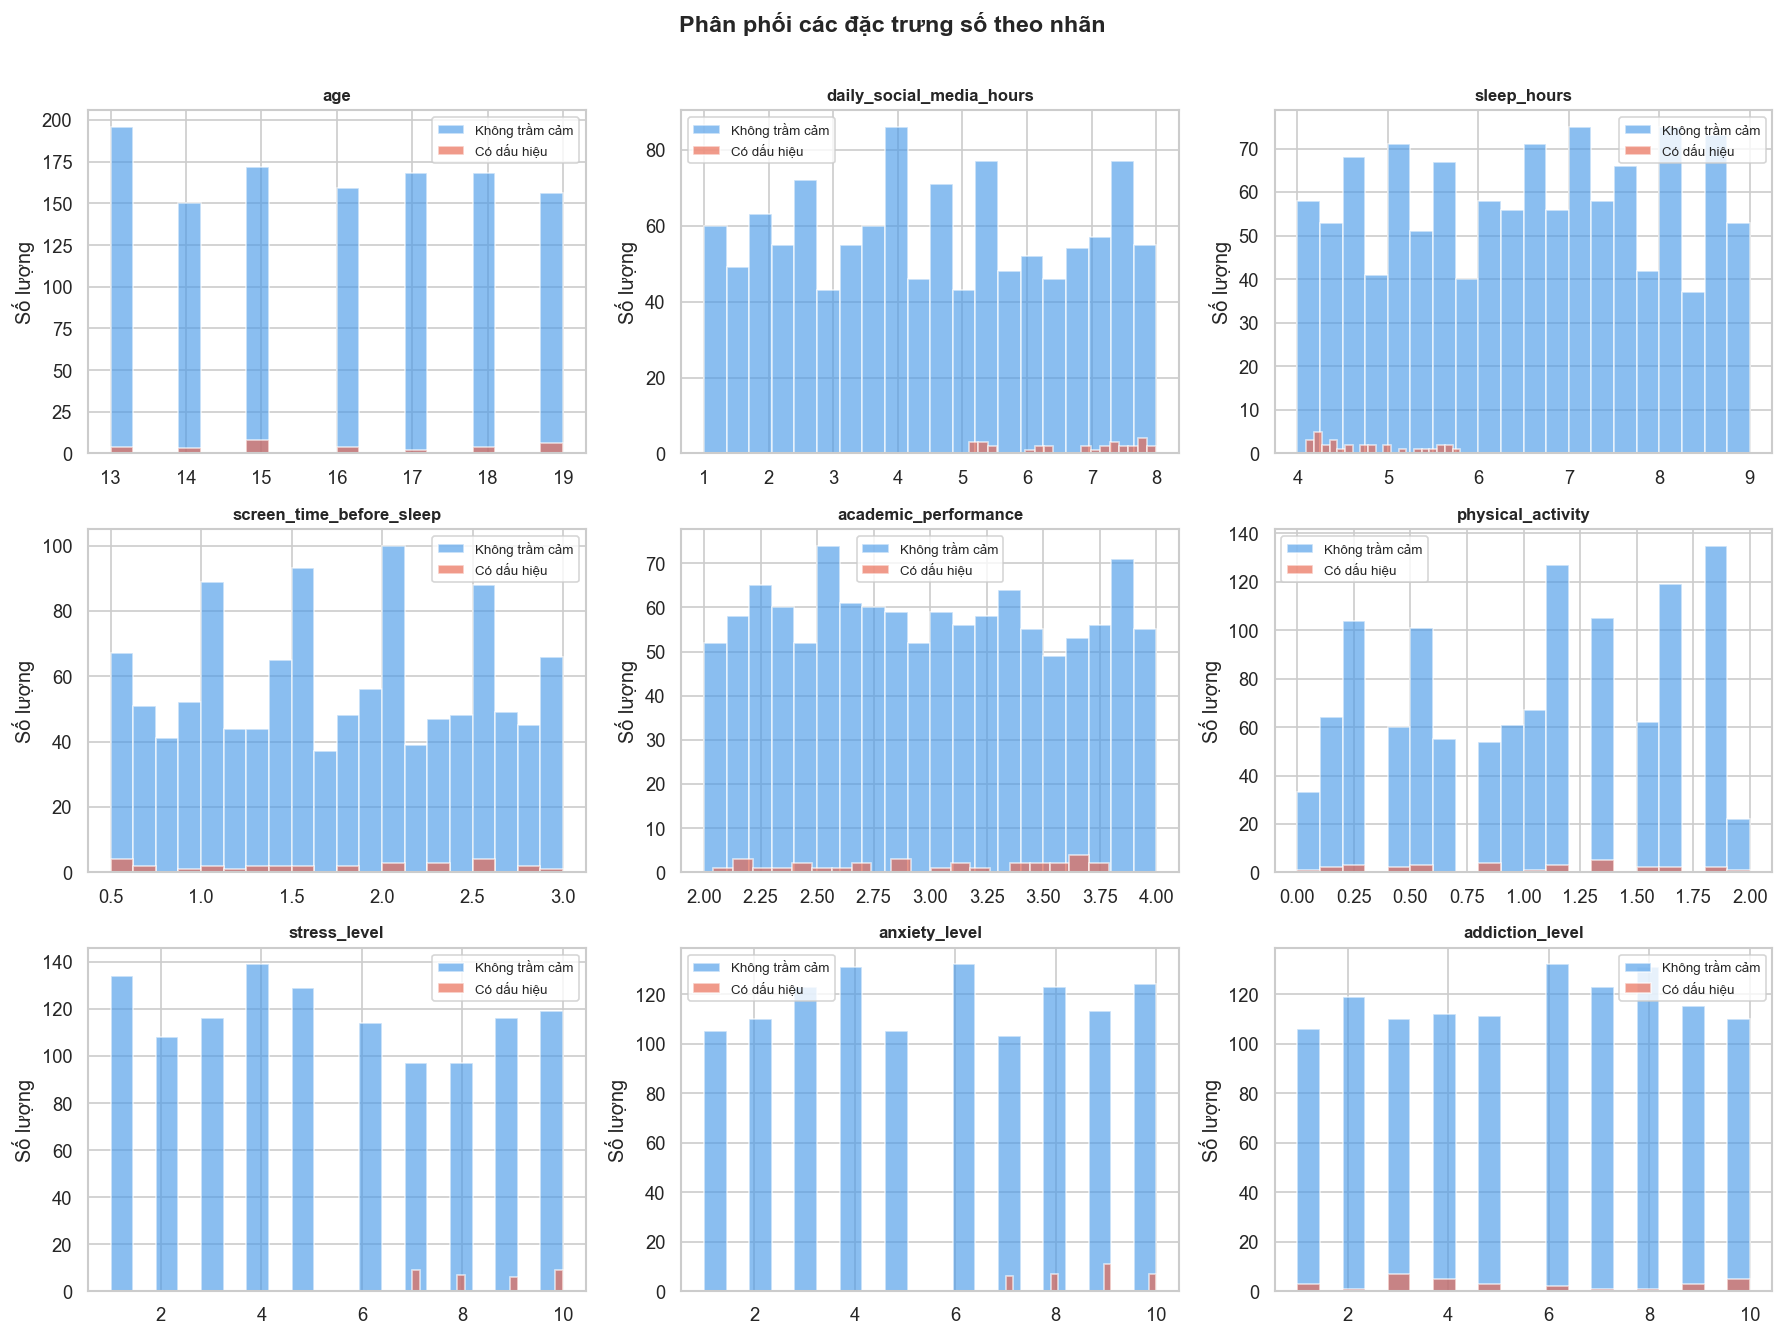

💾 Đã lưu: figures/numeric_distributions.png


In [11]:
# --- 4.2 Histogram các cột số ---
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['depression_label']==0][col], bins=20,
                 alpha=0.65, color='#4C9BE8', label='Không trầm cảm', edgecolor='white')
    axes[i].hist(df[df['depression_label']==1][col], bins=20,
                 alpha=0.65, color='#E8644C', label='Có dấu hiệu', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Số lượng')

plt.suptitle('Phân phối các đặc trưng số theo nhãn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'numeric_distributions.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/numeric_distributions.png')

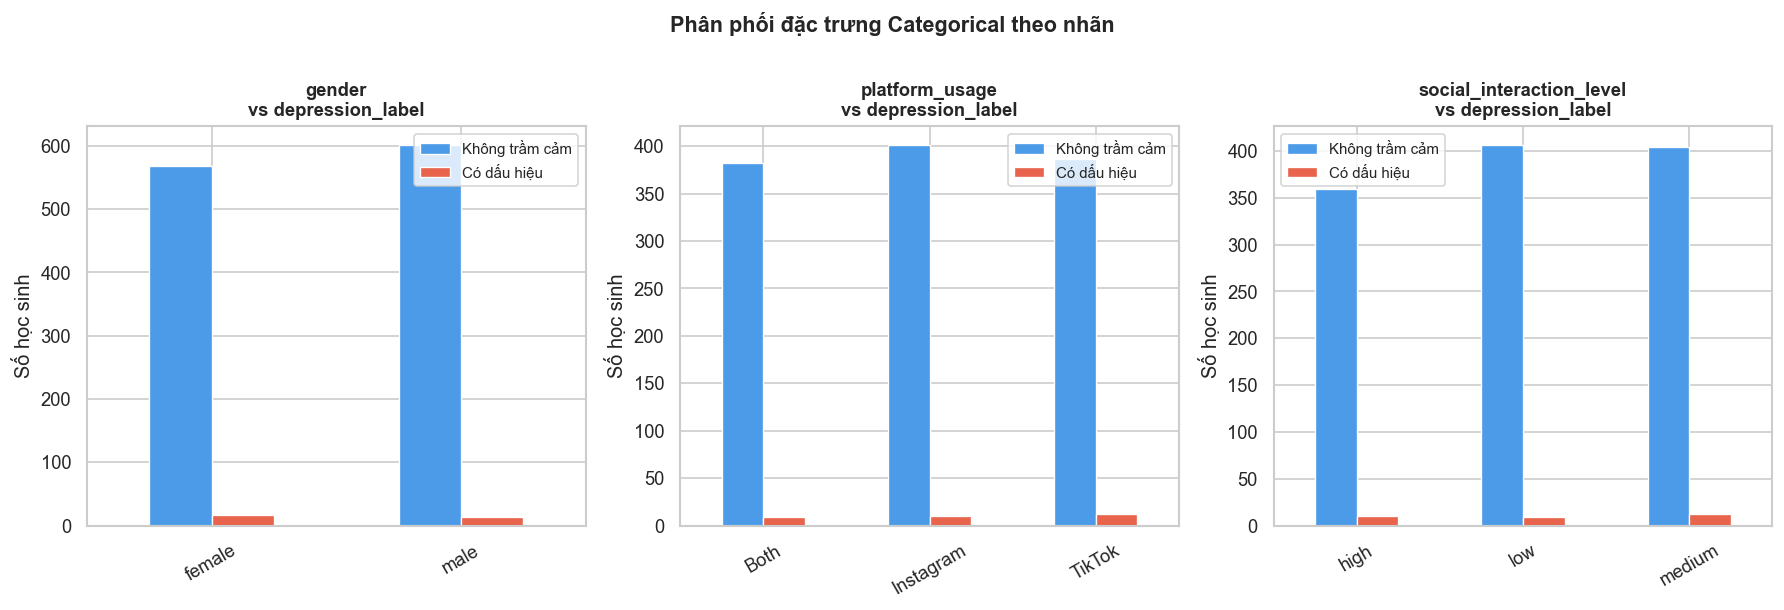

💾 Đã lưu: figures/categorical_distributions.png


In [12]:
# --- 4.3 Biểu đồ cột cho các cột categorical ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['depression_label'])
    ct.columns = ['Không trầm cảm', 'Có dấu hiệu']
    ct.plot(kind='bar', ax=axes[i], color=['#4C9BE8', '#E8644C'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col}\nvs depression_label', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Số học sinh')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)

plt.suptitle('Phân phối đặc trưng Categorical theo nhãn', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'categorical_distributions.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/categorical_distributions.png')

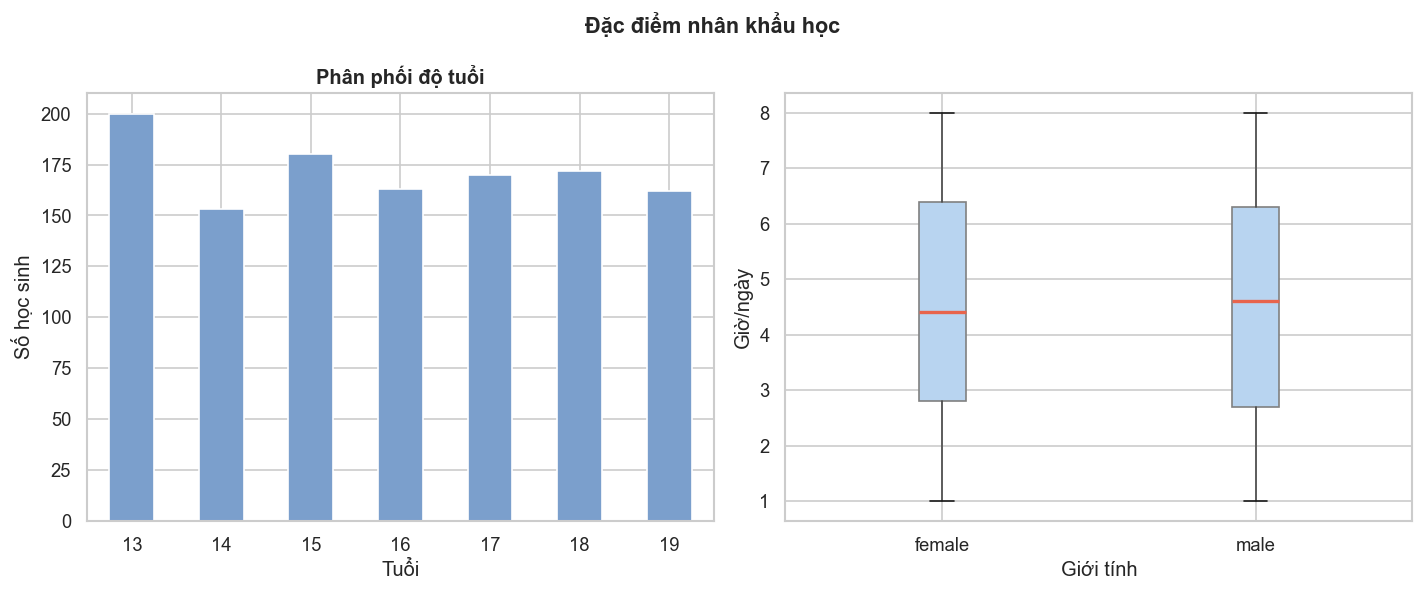

In [13]:
# --- 4.4 Phân phối theo giới tính và độ tuổi ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Độ tuổi
df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='#7B9FCC', edgecolor='white')
axes[0].set_title('Phân phối độ tuổi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số học sinh')
axes[0].tick_params(axis='x', rotation=0)

# Giờ dùng mạng xã hội theo giới tính
df.boxplot(column='daily_social_media_hours', by='gender', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#B8D4F0', color='gray'),
           medianprops=dict(color='#E8644C', linewidth=2))
axes[1].set_title('Giờ dùng MXH theo giới tính', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Giờ/ngày')
plt.sca(axes[1])
plt.title('')

plt.suptitle('Đặc điểm nhân khẩu học', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'demographics.png', bbox_inches='tight')
plt.show()

---
## 5. Phân tích tương quan (Correlation Analysis)

**Tương quan (correlation):** Đo mức độ biến này thay đổi theo biến kia.  
- Giá trị từ **-1 → +1**
- **+1**: tương quan thuận hoàn toàn (biến A tăng → biến B tăng)
- **-1**: tương quan nghịch hoàn toàn (A tăng → B giảm)
- **0**: không tương quan

Thông thường |r| > 0.7 được coi là **tương quan mạnh**.

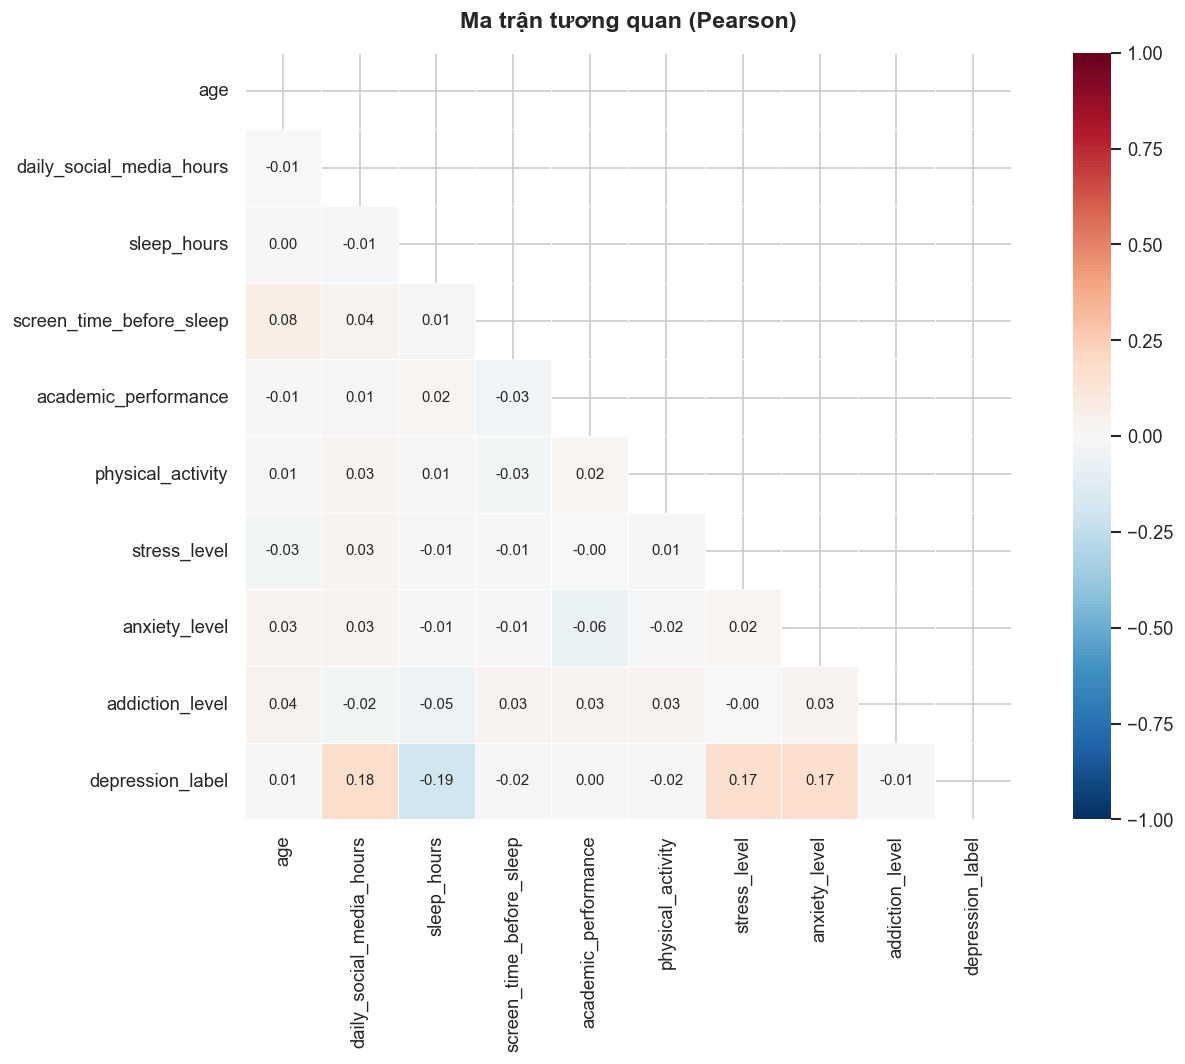

💾 Đã lưu: figures/correlation_heatmap.png


In [14]:
# Tính ma trận tương quan (chỉ dùng cột số)
corr_cols = num_cols + ['depression_label']
corr_matrix = df[corr_cols].corr()

# Heatmap tương quan
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiện nửa dưới

heatmap = sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Ma trận tương quan (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR + 'correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/correlation_heatmap.png')

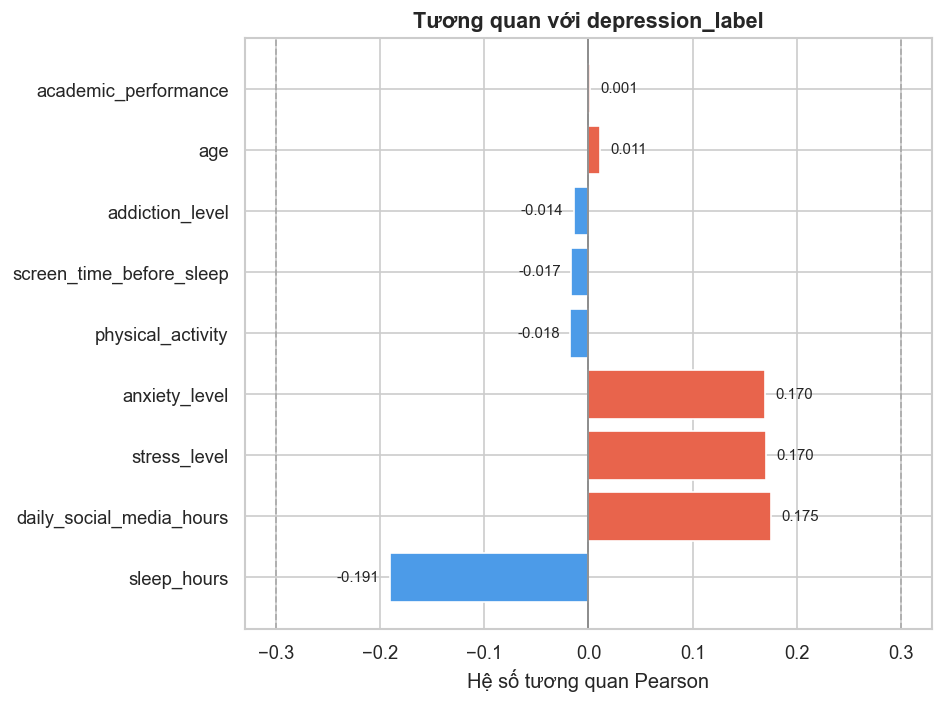


📊 Bảng tương quan với biến mục tiêu:
                          Tương quan
sleep_hours                  -0.1906
daily_social_media_hours      0.1752
stress_level                  0.1705
anxiety_level                 0.1696
physical_activity            -0.0176
screen_time_before_sleep     -0.0165
addiction_level              -0.0140
age                           0.0110
academic_performance          0.0014


In [15]:
# Xem mức độ tương quan của từng đặc trưng với biến mục tiêu
target_corr = corr_matrix['depression_label'].drop('depression_label').sort_values(key=abs, ascending=False)

colors = ['#E8644C' if v > 0 else '#4C9BE8' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=1)
ax.axvline(0.3, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(-0.3, color='gray', linewidth=1, linestyle='--', alpha=0.5)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.01 * np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('Tương quan với depression_label', fontsize=13, fontweight='bold')
ax.set_xlabel('Hệ số tương quan Pearson')
plt.tight_layout()
plt.savefig(FIG_DIR + 'feature_correlation_target.png', bbox_inches='tight')
plt.show()

print('\n📊 Bảng tương quan với biến mục tiêu:')
print(target_corr.to_frame('Tương quan').round(4))

In [16]:
from scipy import stats

group0 = df[df['depression_label'] == 0]
group1 = df[df['depression_label'] == 1]

print('📐 So sánh trung bình giữa 2 nhóm (T-test):')
print(f"{'Đặc trưng':<30} {'TB nhóm 0':>12} {'TB nhóm 1':>12} {'p-value':>10} {'Ý nghĩa':>10}")
print('-' * 80)

for col in num_cols:
    t_stat, p_val = stats.ttest_ind(group0[col].dropna(), group1[col].dropna())
    mean0 = group0[col].mean()
    mean1 = group1[col].mean()
    sig = '✅ Có' if p_val < 0.05 else '❌ Không'
    print(f'{col:<30} {mean0:>12.3f} {mean1:>12.3f} {p_val:>10.4f} {sig:>10}')

print('\n* p-value < 0.05 → Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm')

📐 So sánh trung bình giữa 2 nhóm (T-test):
Đặc trưng                         TB nhóm 0    TB nhóm 1    p-value    Ý nghĩa
--------------------------------------------------------------------------------
age                                  15.925       16.065     0.7042    ❌ Không
daily_social_media_hours              4.479        6.719     0.0000       ✅ Có
sleep_hours                           6.494        4.761     0.0000       ✅ Có
screen_time_before_sleep              1.742        1.668     0.5679    ❌ Không
academic_performance                  2.990        2.995     0.9602    ❌ Không
physical_activity                     1.016        0.952     0.5425    ❌ Không
stress_level                          5.365        8.484     0.0000       ✅ Có
anxiety_level                         5.558        8.613     0.0000       ✅ Có
addiction_level                       5.571        5.323     0.6292    ❌ Không

* p-value < 0.05 → Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm


---
## 6. Tiền xử lý dữ liệu (Preprocessing)

### 6.1 Xử lý Missing Values

Mặc dù dataset này không có missing values, ta vẫn viết code chuẩn để xử lý:
- **Cột số:** điền bằng **median** (trung vị — ít bị ảnh hưởng bởi outlier hơn mean)
- **Cột chữ:** điền bằng **mode** (giá trị xuất hiện nhiều nhất)

In [17]:
df_processed = df.copy()  # luôn làm việc trên bản sao, giữ nguyên dữ liệu gốc

# Điền missing values
for col in df_processed.select_dtypes(include='number').columns:
    if df_processed[col].isnull().any():
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f'  Cột số [{col}]: điền bằng median = {median_val:.2f}')

for col in df_processed.select_dtypes(include='object').columns:
    if df_processed[col].isnull().any():
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f'  Cột chữ [{col}]: điền bằng mode = {mode_val}')

print(f'✅ Sau xử lý: {df_processed.isnull().sum().sum()} missing values còn lại')

✅ Sau xử lý: 0 missing values còn lại


### 6.2 Encoding Categorical Variables

Mô hình machine learning **chỉ hiểu con số**, không hiểu chữ.  
Ta cần chuyển đổi các cột chữ sang dạng số:

- **Label Encoding**: chuyển thành 0, 1, 2, ... — phù hợp khi có thứ tự (low/medium/high)
- **One-Hot Encoding**: tạo cột 0/1 cho từng giá trị — phù hợp khi không có thứ tự (Instagram/TikTok/Both)

In [18]:
# --- gender: male=0, female=1 ---
df_processed['gender'] = df_processed['gender'].map({'male': 0, 'female': 1})
print('gender encoded:', df_processed['gender'].unique())

# --- social_interaction_level: có thứ tự nên dùng Label Encoding có kiểm soát ---
interaction_order = {'low': 0, 'medium': 1, 'high': 2}
df_processed['social_interaction_level'] = df_processed['social_interaction_level'].map(interaction_order)
print('social_interaction_level encoded:', df_processed['social_interaction_level'].unique())

# --- platform_usage: không có thứ tự → One-Hot Encoding ---
platform_dummies = pd.get_dummies(df_processed['platform_usage'], prefix='platform', dtype=int)
df_processed = pd.concat([df_processed.drop('platform_usage', axis=1), platform_dummies], axis=1)
print('platform_usage columns:', [c for c in df_processed.columns if 'platform' in c])

print(f'\n📋 Số cột sau encoding: {df_processed.shape[1]}')
df_processed.head(3)

gender encoded: [0 1]
social_interaction_level encoded: [0 2 1]
platform_usage columns: ['platform_Both', 'platform_Instagram', 'platform_TikTok']

📋 Số cột sau encoding: 15


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_Both,platform_Instagram,platform_TikTok
0,14,0,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,0,1,0
1,19,1,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,0,0,1
2,17,1,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,0,1,0


### 6.3 Feature Scaling (Chuẩn hóa)

Các đặc trưng số có **đơn vị và phạm vi khác nhau** (vd: age 13–19 vs anxiety_level 1–10).  
**StandardScaler** chuyển mỗi cột về dạng: mean=0, std=1

$$z = \frac{x - \mu}{\sigma}$$

> **Lưu ý:** Không scale cột mục tiêu (`depression_label`) và cột binary (0/1)

---
## 7. Feature Engineering

**Feature Engineering** là tạo thêm các đặc trưng mới từ dữ liệu có sẵn để mô hình học tốt hơn.

Ta sẽ tạo 4 đặc trưng mới — *tất cả được tạo TRÊN dữ liệu gốc (`df_processed`) trước khi scale*:

In [19]:
# Làm việc trên df_processed (đã encode, chưa scale) để tính ngưỡng có nghĩa hơn
df_fe = df_processed.copy()

# 1. Social Media / Sleep Ratio
# Ý nghĩa: dùng MXH bao nhiêu giờ trên mỗi giờ ngủ
# Giá trị cao → mất cân bằng giữa MXH và giấc ngủ
df_fe['sm_sleep_ratio'] = df_fe['daily_social_media_hours'] / (df_fe['sleep_hours'] + 1e-6)

# 2. Screen Time Before Sleep Ratio
# Ý nghĩa: tỉ lệ thời gian nhìn màn hình trước ngủ so với tổng giờ ngủ
df_fe['screen_sleep_ratio'] = df_fe['screen_time_before_sleep'] / (df_fe['sleep_hours'] + 1e-6)

# 3. Heavy Social Media User Flag
# Ý nghĩa: đánh dấu người dùng "nặng" (trên ngưỡng 75th percentile)
heavy_threshold = df_fe['daily_social_media_hours'].quantile(0.75)
df_fe['heavy_sm_user'] = (df_fe['daily_social_media_hours'] > heavy_threshold).astype(int)

# 4. Low Sleep Indicator
# Ý nghĩa: thanh thiếu niên cần 8-10h ngủ/ngày; < 6h là thiếu ngủ
df_fe['low_sleep'] = (df_fe['sleep_hours'] < 6).astype(int)

print(f'Ngưỡng "heavy user": {heavy_threshold:.2f} giờ/ngày')
print(f'Số heavy users: {df_fe["heavy_sm_user"].sum()} ({df_fe["heavy_sm_user"].mean()*100:.1f}%)')
print(f'Số low sleep:   {df_fe["low_sleep"].sum()} ({df_fe["low_sleep"].mean()*100:.1f}%)')
print(f'\n📋 4 đặc trưng mới:')
df_fe[['sm_sleep_ratio', 'screen_sleep_ratio', 'heavy_sm_user', 'low_sleep']].describe().round(3)

Ngưỡng "heavy user": 6.30 giờ/ngày
Số heavy users: 298 (24.8%)
Số low sleep:   480 (40.0%)

📋 4 đặc trưng mới:


,sm_sleep_ratio,screen_sleep_ratio,heavy_sm_user,low_sleep
count,1200.000,1200.000,1200.000,1200.00
mean,0.742,0.284,0.248,0.40
std,0.382,0.138,0.432,0.49
min,0.118,0.061,0.000,0.00
25%,0.427,0.172,0.000,0.00
50%,0.721,0.266,0.000,0.00
75%,0.976,0.368,0.000,1.00
max,1.927,0.725,1.000,1.00


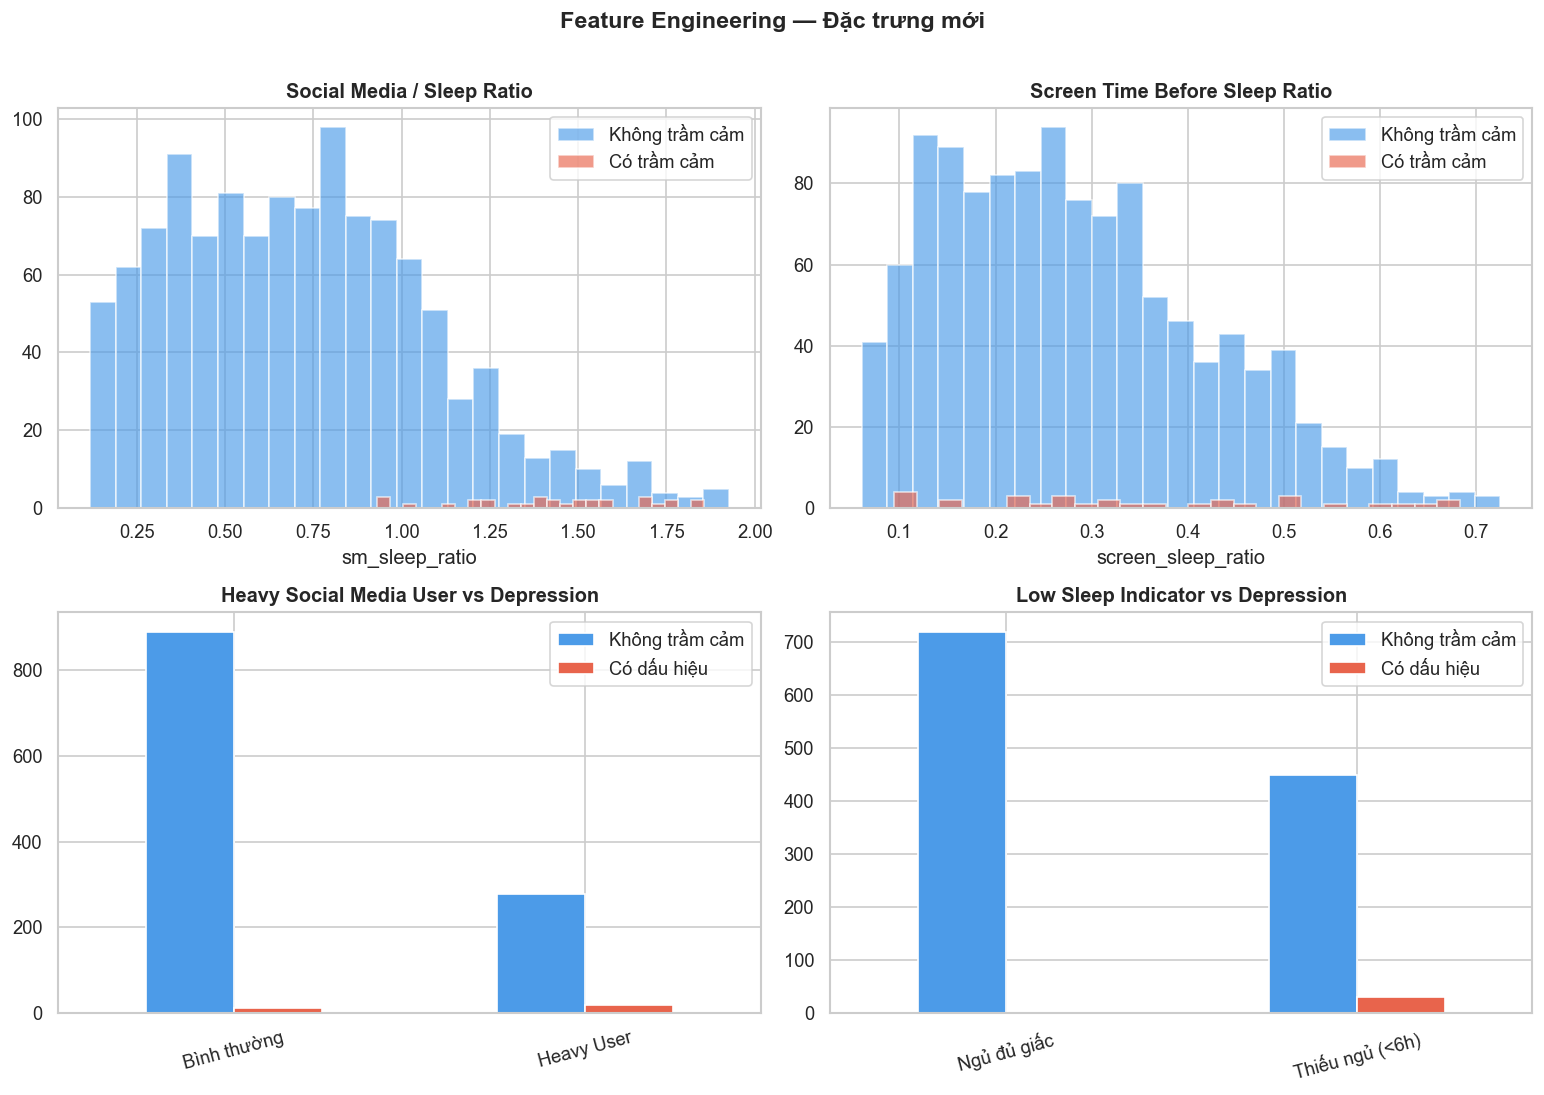

💾 Đã lưu: figures/feature_engineering.png


In [20]:
# Trực quan hóa đặc trưng mới
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# sm_sleep_ratio
for label, color, name in [(0, '#4C9BE8', 'Không'), (1, '#E8644C', 'Có')]:
    axes[0,0].hist(df_fe[df_fe['depression_label']==label]['sm_sleep_ratio'],
                   bins=25, alpha=0.65, color=color, label=f'{name} trầm cảm', edgecolor='white')
axes[0,0].set_title('Social Media / Sleep Ratio', fontweight='bold')
axes[0,0].legend(); axes[0,0].set_xlabel('sm_sleep_ratio')

# screen_sleep_ratio
for label, color, name in [(0, '#4C9BE8', 'Không'), (1, '#E8644C', 'Có')]:
    axes[0,1].hist(df_fe[df_fe['depression_label']==label]['screen_sleep_ratio'],
                   bins=25, alpha=0.65, color=color, label=f'{name} trầm cảm', edgecolor='white')
axes[0,1].set_title('Screen Time Before Sleep Ratio', fontweight='bold')
axes[0,1].legend(); axes[0,1].set_xlabel('screen_sleep_ratio')

# heavy_sm_user
ct1 = pd.crosstab(df_fe['heavy_sm_user'], df_fe['depression_label'])
ct1.index = ['Bình thường', 'Heavy User']
ct1.columns = ['Không trầm cảm', 'Có dấu hiệu']
ct1.plot(kind='bar', ax=axes[1,0], color=['#4C9BE8', '#E8644C'], edgecolor='white')
axes[1,0].set_title('Heavy Social Media User vs Depression', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# low_sleep
ct2 = pd.crosstab(df_fe['low_sleep'], df_fe['depression_label'])
ct2.index = ['Ngủ đủ giấc', 'Thiếu ngủ (<6h)']
ct2.columns = ['Không trầm cảm', 'Có dấu hiệu']
ct2.plot(kind='bar', ax=axes[1,1], color=['#4C9BE8', '#E8644C'], edgecolor='white')
axes[1,1].set_title('Low Sleep Indicator vs Depression', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Engineering — Đặc trưng mới', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + 'feature_engineering.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/feature_engineering.png')

In [26]:
scale_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
              'screen_time_before_sleep', 'academic_performance',
              'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level',
              'social_interaction_level', 'sm_sleep_ratio', 'screen_sleep_ratio']

df_fe[scale_cols] = StandardScaler().fit_transform(df_fe[scale_cols])

print('✅ Đã scale tất cả đặc trưng liên tục')
print(f'Dataset hiện tại: {df_fe.shape[0]} hàng × {df_fe.shape[1]} cột')


✅ Đã scale tất cả đặc trưng liên tục
Dataset hiện tại: 1200 hàng × 19 cột


---
## 8. Xử lý dữ liệu mất cân bằng (Class Imbalance)

**Vấn đề:** Chỉ **2.6%** dữ liệu thuộc lớp 1 — mô hình sẽ học cách dự đoán "luôn luôn là 0" và đạt ~97% accuracy mà không học được gì thực sự!

### Hai cách xử lý:

| Phương pháp | Ý tưởng | Khi nào dùng |
|---|---|---|
| **SMOTE** | Tạo thêm mẫu tổng hợp cho lớp thiểu số | Khi muốn cân bằng hoàn toàn |
| **Class Weight** | Phạt nặng hơn khi sai lớp thiểu số | Khi không muốn thay đổi dữ liệu gốc |

> **Lưu ý:** SMOTE ở đây áp dụng để chuẩn bị dữ liệu. Khi train mô hình thực tế, nên split train/test trước rồi mới SMOTE trên tập train.

In [27]:
# Tách X (đặc trưng) và y (nhãn)
X = df_fe.drop('depression_label', axis=1)
y = df_fe['depression_label']

print(f'X shape: {X.shape}')
print(f'y phân phối:\n{y.value_counts().to_string()}')
print(f'\nTỉ lệ: {y.value_counts()[1]/len(y)*100:.1f}% có dấu hiệu trầm cảm')

X shape: (1200, 18)
y phân phối:
depression_label
0    1169
1      31

Tỉ lệ: 2.6% có dấu hiệu trầm cảm


📊 Sau SMOTE:
  X: (2338, 18)
  y phân phối: {0: np.int64(1169), 1: np.int64(1169)}


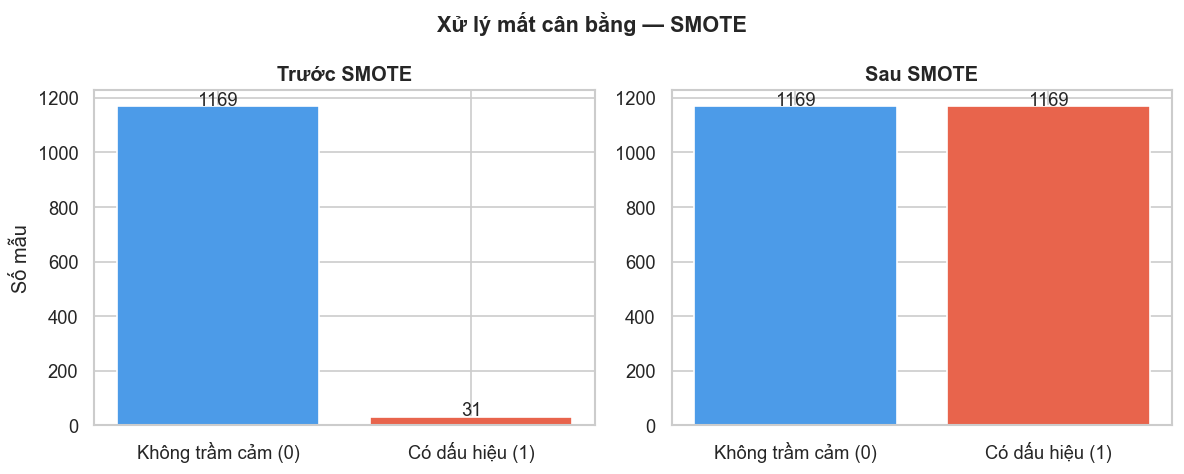

💾 Đã lưu: figures/smote_comparison.png


In [28]:
# --- 8.1 SMOTE (Synthetic Minority Over-sampling Technique) ---
# Tạo thêm mẫu nhân tạo bằng cách nội suy giữa các mẫu hiện có của lớp thiểu số

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print('📊 Sau SMOTE:')
print(f'  X: {X_smote.shape}')
print(f'  y phân phối: {dict(pd.Series(y_smote).value_counts())}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_counts_orig  = y.value_counts()
y_counts_smote = pd.Series(y_smote).value_counts()
labels_bar = ['Không trầm cảm (0)', 'Có dấu hiệu (1)']

axes[0].bar(labels_bar, y_counts_orig.sort_index().values,
            color=['#4C9BE8', '#E8644C'], edgecolor='white')
axes[0].set_title('Trước SMOTE', fontweight='bold')
axes[0].set_ylabel('Số mẫu')
for i, v in enumerate(y_counts_orig.sort_index().values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

axes[1].bar(labels_bar, y_counts_smote.sort_index().values,
            color=['#4C9BE8', '#E8644C'], edgecolor='white')
axes[1].set_title('Sau SMOTE', fontweight='bold')
for i, v in enumerate(y_counts_smote.sort_index().values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.suptitle('Xử lý mất cân bằng — SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'smote_comparison.png', bbox_inches='tight')
plt.show()
print('💾 Đã lưu: figures/smote_comparison.png')

In [29]:
# --- 8.2 Class Weighting ---
# Không thay đổi dữ liệu, chỉ truyền class_weight vào mô hình khi train
# sklearn tự động tính: class_weight = n_samples / (n_classes * n_samples_per_class)

from sklearn.utils import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(enumerate(class_weights))

print('⚖️ Class weights (dùng khi train mô hình):')
print(f'  Lớp 0 (Không trầm cảm): weight = {class_weight_dict[0]:.4f}')
print(f'  Lớp 1 (Có dấu hiệu):    weight = {class_weight_dict[1]:.4f}')
print()
print('💡 Ví dụ cách dùng khi train:')
print('  LogisticRegression(class_weight="balanced")')
print('  RandomForestClassifier(class_weight="balanced")')
print('  XGBClassifier(scale_pos_weight=n_neg/n_pos)')

⚖️ Class weights (dùng khi train mô hình):
  Lớp 0 (Không trầm cảm): weight = 0.5133
  Lớp 1 (Có dấu hiệu):    weight = 19.3548

💡 Ví dụ cách dùng khi train:
  LogisticRegression(class_weight="balanced")
  RandomForestClassifier(class_weight="balanced")
  XGBClassifier(scale_pos_weight=n_neg/n_pos)


---
## 9. Lưu kết quả

Lưu hai phiên bản:
1. **Dữ liệu đã xử lý** (không SMOTE) — dùng khi huấn luyện với `class_weight`
2. **Dữ liệu SMOTE** — dùng khi huấn luyện các mô hình không hỗ trợ class weight

In [30]:
# Lưu dataset đã xử lý (chưa SMOTE)
df_fe.to_csv(PROC_PATH, index=False)
print(f'✅ Đã lưu: {PROC_PATH} — shape: {df_fe.shape}')

# Lưu dataset sau SMOTE
df_smote = pd.DataFrame(X_smote, columns=X.columns)
df_smote['depression_label'] = y_smote.values
smote_path = '../data/processed/smote_data.csv'
df_smote.to_csv(smote_path, index=False)
print(f'✅ Đã lưu: {smote_path} — shape: {df_smote.shape}')

# Lưu class weights để dùng lại
import json
with open('../data/processed/class_weights.json', 'w') as f:
    json.dump(class_weight_dict, f, indent=2)
print(f'✅ Đã lưu: ../data/processed/class_weights.json')

✅ Đã lưu: ../data/processed/preprocessed_data.csv — shape: (1200, 19)
✅ Đã lưu: ../data/processed/smote_data.csv — shape: (2338, 19)
✅ Đã lưu: ../data/processed/class_weights.json


In [ ]:
# --- Tóm tắt toàn bộ quá trình ---
print('=' * 60)
print('  TÓM TẮT EDA & PREPROCESSING')
print('=' * 60)
print(f'Dataset gốc:          {df.shape[0]} hàng × {df.shape[1]} cột')
print(f'Missing values:       {df.isnull().sum().sum()} (không có)')
print(f'Sau Encoding:         {df_processed.shape[1]} cột')
print(f'Sau Feature Eng.:     {df_fe.shape[1]} cột (+4 đặc trưng mới)')
print(f'Sau SMOTE:            {df_smote.shape[0]} hàng (cân bằng 50/50)')
print()
print('Biến mục tiêu (gốc):')
vc = df['depression_label'].value_counts()
print(f'  0 (không):  {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  1 (có):     {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print()
print('Các file đã lưu:')
print('  📁 data/processed/preprocessed_data.csv')
print('  📁 data/processed/smote_data.csv')
print('  📁 data/processed/class_weights.json')
print('  📁 figures/eda/*.png (8 biểu đồ)')
print('=' * 60)